# **Demo 03: Building a Reactive Agent Workflow with LangGraph and Tavily**

**Objective:** To demonstrate how to build a reactive AI agent using the LangGraph framework integrated with LangChain’s Tavily search tool. This demo guides learners through creating a react-style agent using create_react_agent(), connecting it to a real-time web search function, and invoking the agent to respond dynamically to user queries. The focus is on showcasing how LangGraph enables modular, tool-enhanced agent workflows for tasks that require external information retrieval and context-aware decision-making

**Prerequisites:** Tavily key, OpenAI API key 

**Tools required:** Python

**Scenario:** : A product lead at a fintech startup wants to monitor global developments in real-time fraud detection methods for UPI systems. The manual process of tracking cybersecurity advancements and regulatory changes is inefficient and prone to oversight. The goal is to automate this workflow using LangGraph, where an agent uses a search tool to gather the latest research and another agent validates and summarizes the findings for internal teams.

In [9]:
# Step 1: Install required libraries
#
# langgraph         — the graph execution framework; provides create_react_agent and graph compilation
# langchain-openai  — LangChain's OpenAI integration; provides ChatOpenAI
# langchain-tavily  — LangChain wrapper for the Tavily search API; provides TavilySearch as a tool
# tavily-python     — Tavily's official Python client (required by langchain-tavily internally)
# python-dotenv     — loads key=value pairs from a .env file into os.environ

!pip install langgraph langchain-openai langchain-tavily tavily-python python-dotenv

In [10]:
# Step 2: Load API credentials from .env
#
# Keeping secrets in a .env file (rather than hardcoded in the notebook) means
# the notebook can be shared or committed to version control safely.
# load_dotenv() scans the current directory (and parent directories) for a .env
# file and copies its key=value pairs into os.environ.
#
# Keys loaded here:
#   OPENAI_API_KEY  — authenticates requests to the OpenAI API; picked up
#                     automatically by ChatOpenAI without explicit reference
#   TAVILY_API_KEY  — authenticates requests to the Tavily search API; picked
#                     up automatically by TavilySearch without explicit reference

import os
from dotenv import load_dotenv

load_dotenv()  # loads OPENAI_API_KEY and TAVILY_API_KEY from .env

print("Credentials loaded from .env")

Credentials loaded from .env


In [11]:
# Step 3: Create the LLM object
#
# ChatOpenAI is LangChain's wrapper around OpenAI's chat completion API.
# It automatically reads OPENAI_API_KEY from os.environ (set by load_dotenv()
# in Step 2), so no key needs to be passed explicitly here.
#
# Parameters:
#   model       — the OpenAI model to use; gpt-4o-mini balances cost and capability
#   temperature — controls output randomness; 0.3 keeps responses focused and
#                 reproducible while allowing some natural variation

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.3,
)

print("LLM ready: gpt-4o-mini")

LLM ready: gpt-4o-mini


In [12]:
# Step 4: Build the Tavily search tool
#
# KEY CONCEPT — Tools give agents the ability to act:
#   A LangChain tool is an object with a name, a description, and a callable.
#   The agent's LLM reads the description to decide WHEN and HOW to invoke the
#   tool. The description is therefore critical — a vague description causes
#   the agent to call the tool at the wrong time (or not at all).
#
# TavilySearch is a pre-built LangChain tool that calls the Tavily web search
# API. It automatically reads TAVILY_API_KEY from os.environ.
#
# Parameters:
#   max_results — limits the number of search results returned per query;
#                 3 results keeps the context concise without losing coverage

from langchain_tavily import TavilySearch

# TavilySearch is already a LangChain-compatible tool — pass it directly to the agent.
search_tool = TavilySearch(max_results=3)

print(f"Tool ready: '{search_tool.name}'")

Tool ready: 'tavily_search'


In [13]:
# Step 5: Create a ReAct agent with LangGraph
#
# KEY CONCEPT — The ReAct (Reason + Act) loop:
#   create_react_agent() builds a LangGraph graph that implements the ReAct
#   pattern. On each turn the LLM either:
#     • emits a tool call  → LangGraph executes the tool and feeds the result
#                            back to the LLM for the next reasoning step
#     • returns a message  → the loop ends and the message is the final answer
#
#   This loop repeats until the LLM produces a plain-text response with no
#   tool calls. The agent therefore uses the search tool only when it judges
#   that the query requires real-time or external information.
#
# Arguments:
#   model — the LLM that drives the ReAct reasoning loop
#   tools — list of tools the agent is allowed to call; add more tools here
#            to extend the agent's capabilities without changing any other code

from langgraph.prebuilt import create_react_agent

agent = create_react_agent(model=llm, tools=[search_tool])

print("ReAct agent created.")

ReAct agent created.


/var/folders/z9/5bc079rj6mb1hfr1tlzf8tlh0000gn/T/ipykernel_18145/3110924450.py:21: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(model=llm, tools=[search_tool])


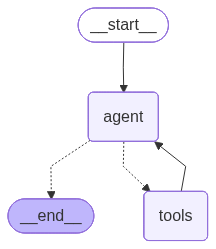

In [14]:
# Step 6: Visualise the agent graph
#
# Displaying the compiled graph object renders a diagram of the ReAct loop:
#   __start__ → agent (LLM) → tools (if a tool call was made) → agent → ... → __end__
#
# This confirms that the graph was compiled correctly and shows the nodes and
# edges that LangGraph will traverse when invoke() is called.
agent

In [15]:
# Step 7a: Invoke the agent on a query that REQUIRES web search
#
# This query asks for current fraud detection methods — information that
# changes frequently and is not reliably covered by the LLM's training data.
#
# Expected agent loop:
#   Turn 1: LLM reads the query → decides to call tavily_search
#   Tool:   TavilySearch runs  → returns real-time articles and summaries
#   Turn 2: LLM reads the search results → composes a grounded final answer
#
# invoke() manages the full ReAct loop and blocks until a final answer is produced.
# Input format: {"messages": [{"role": "user", "content": "..."}]}
# Output: a state dict whose "messages" list contains every turn, ending with
#         the agent's final AIMessage.

state = agent.invoke({
    "messages": [
        {"role": "user", "content": "What are the latest fraud detection methods in UPI systems?"}
    ]
})

# Print the full state to inspect every turn: user message, tool calls, tool results,
# and the final answer. In production you would access state["messages"][-1].content
# to get only the agent's final response.
print("\n[Agent response — with Tavily web search]:\n")
print(state["messages"][-1].content)


[Agent response — with Tavily web search]:

Here are some of the latest developments in fraud detection methods relevant to UPI (Unified Payments Interface) systems:

1. **AI-Driven Tools**: Financial institutions, such as Lloyds Banking Group, are increasingly using AI to combat fraud in real-time. They have invested significantly in AI technologies to enhance decision-making and proactively prevent fraud. This shift from reactive to proactive fraud detection is becoming a trend across the industry.

   - **Source**: [FinTech Magazine](https://fintechmagazine.com/news/how-lloyds-is-using-agentic-ai-to-fight-fraud-in-real-time)

2. **Regulatory Actions**: The Federal Trade Commission (FTC) has been active in enforcing regulations to eliminate fraud in payment systems. Recent actions include significant penalties against companies that have violated orders aimed at preventing consumer fraud. This highlights the importance of compliance and monitoring in fraud detection.

   - **Source*

In [16]:
# Step 7b: Invoke the agent on a query that does NOT require web search
#
# This query asks for simple arithmetic — information the LLM can answer
# entirely from its own knowledge without calling any external tool.
#
# Expected agent loop:
#   Turn 1: LLM reads the query → answers directly, no tool call issued
#
# Comparing this output with Step 7a demonstrates that the agent decides
# AUTONOMOUSLY when a tool is needed. You do not need to instruct it —
# the LLM reasons about the query and selects the appropriate action.

state = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is 2 + 3?"}
    ]
})

print("\n[Agent response — no tool needed]:\n")
print(state["messages"][-1].content)


[Agent response — no tool needed]:

2 + 3 equals 5.


#### By following these steps, you have successfully built a reactive AI agent with LangGraph, integrated LangChain’s Tavily search, created it via create_react_agent(), connected real-time web search, and invoked it to respond dynamically to user queries—showcasing LangGraph’s modular, tool-enhanced workflows for external retrieval and context-aware decision-making.